# Comparativa: top‑5 semántico vs. top‑5 por centralidad

Para cada oración del corpus AnCora 2.0:

1. Extrae el **grafo semántico-sintáctico** con `ExtractorGrafo` (de `tree_balance.py`) y obtiene el **top‑5 semántico** vía `extraer_top5` (verbo principal + agente + argumentos, sin funcionales ni circunstancias).
2. Carga el **árbol de dependencia sintáctica** correspondiente desde `AnCora-ES/<corpus>_<archivo>_s<NNNNN>.graphml`.
3. Sobre el árbol no dirigido, calcula 5 medidas de centralidad: Betweenness, Closeness, Harmonic, All-Subgraphs, PageRank.
4. Mapea cada score de nodo (ID = índice de token) a su `form` (palabra) y deduplica para sacar el **top‑5 por centralidad** (5 palabras únicas con mayor centralidad).
5. Compara las dos listas:
   - **Intersección** ∈ [0, 5] (↑ más alto = más coincidencia).
   - **Distancia de Levenshtein** ∈ [0, 5] entre las listas ordenadas (↓ más bajo = más parecidas).
6. Agrega media y desviación estándar por medida.

**Nota:** el top‑5 de centralidad es crudo (no filtra funcionales/auxiliares). El top‑5 semántico ya los excluye por las reglas de `extraer_top5`.

In [8]:
!pip install -U networkx


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [9]:
import csv
import statistics
import sys
import xml.etree.ElementTree as ET
from pathlib import Path

# Compatibilidad NumPy 2.x ↔ networkx <3.4
import numpy as np
for _attr, _alias in [("float_", "float64"), ("int_", "int64")]:
    if not hasattr(np, _attr):
        setattr(np, _attr, getattr(np, _alias))

import matplotlib.pyplot as plt
import networkx as nx

sys.path.insert(0, str(Path.cwd() / "scripts"))
from tree_balance import ExtractorGrafo, extraer_top5
from asg_cen.all_subgraphs_centrality import all_subgraphs_centrality

CARPETA_XML = Path("/Users/summa/Documents/Cenia/C. Riveros/data/ancora-dep-2.0/xml")
CARPETA_DEP = Path("AnCora-ES")
RESULTADOS_CSV = Path("top5_centrality_comparison.csv")
RESUMEN_CSV = Path("top5_centrality_summary.csv")

METODOS = ["Betweenness", "Closeness", "Harmonic", "All-Subgraphs", "PageRank"]

assert CARPETA_XML.exists(), CARPETA_XML
assert CARPETA_DEP.exists(), CARPETA_DEP

In [10]:
def cargar_dep_tree(corpus, base, idx):
    """Carga el .graphml del árbol de dependencia para una oración.
    Devuelve (G_undirected, formas_dict) o (None, None) si no existe."""
    ruta = CARPETA_DEP / f"{corpus}_{base}_s{idx:05d}.graphml"
    if not ruta.exists():
        return None, None
    G = nx.read_graphml(ruta)
    formas = {n: data.get("form", str(n)) for n, data in G.nodes(data=True)}
    return G.to_undirected(), formas


def centralidad(G, metodo):
    if metodo == "Betweenness":
        return nx.betweenness_centrality(G)
    if metodo == "Closeness":
        return nx.closeness_centrality(G)
    if metodo == "Harmonic":
        return nx.harmonic_centrality(G)
    if metodo == "PageRank":
        return nx.pagerank(G)
    if metodo == "All-Subgraphs":
        return all_subgraphs_centrality(G)
    raise ValueError(metodo)


def top5_formas(scores, formas, k=5):
    """Top-k formas únicas ordenadas por score descendente.
    Cuando varios tokens comparten la misma forma (p. ej. varios 'de'),
    se conserva el de mayor centralidad y se descartan los duplicados."""
    nodos_ord = sorted(scores.items(), key=lambda it: (-it[1], str(it[0])))
    vistas, top = set(), []
    for nodo, _ in nodos_ord:
        forma = formas.get(nodo, str(nodo))
        if forma in vistas:
            continue
        vistas.add(forma)
        top.append(forma)
        if len(top) >= k:
            break
    return top


def levenshtein(a, b):
    """Distancia de edición entre dos secuencias arbitrarias."""
    m, n = len(a), len(b)
    if m == 0:
        return n
    if n == 0:
        return m
    prev = list(range(n + 1))
    for i in range(1, m + 1):
        curr = [i] + [0] * n
        for j in range(1, n + 1):
            cost = 0 if a[i - 1] == b[j - 1] else 1
            curr[j] = min(prev[j] + 1, curr[j - 1] + 1, prev[j - 1] + cost)
        prev = curr
    return prev[n]


def interseccion(a, b):
    return len(set(a) & set(b))


def listar_xml(carpeta):
    archivos = []
    for sub in sorted(carpeta.iterdir()):
        if sub.is_dir():
            archivos.extend(sorted(sub.rglob("*.tbf.xml")))
    if not archivos:
        archivos = sorted(carpeta.rglob("*.tbf.xml"))
    return archivos

## Loop principal

Por defecto procesa los 1635 archivos XML (~17k oraciones). Para probar más rápido,
fija `LIMITE_ARCHIVOS` a un número pequeño (p. ej. 20).

In [11]:
LIMITE_ARCHIVOS = None       # None para procesar todo; entero para limitar
PROGRESO_CADA = 50           # imprimir progreso cada N archivos
FORZAR_RECOMPUTAR = False    # True para recomputar aunque exista el CSV

# Columnas que deben castearse a int al recargar desde CSV
COLS_INT = ["oracion", "n_nodos_dep", "n_top5_sem"] + \
           [f"inter_{m}" for m in METODOS] + \
           [f"leven_{m}" for m in METODOS]


def cargar_desde_csv(ruta):
    filas_csv = []
    with open(ruta, encoding="utf-8") as f:
        for r in csv.DictReader(f):
            for c in COLS_INT:
                if c in r and r[c] != "":
                    r[c] = int(r[c])
            filas_csv.append(r)
    return filas_csv


if RESULTADOS_CSV.exists() and not FORZAR_RECOMPUTAR:
    filas = cargar_desde_csv(RESULTADOS_CSV)
    print(f"Cargado desde {RESULTADOS_CSV}: {len(filas)} filas (sin recomputar).")
    print(f"Si quieres recalcular, fija FORZAR_RECOMPUTAR = True.")
else:
    archivos = listar_xml(CARPETA_XML)
    if LIMITE_ARCHIVOS:
        archivos = archivos[:LIMITE_ARCHIVOS]
    print(f"Archivos a procesar: {len(archivos)}")

    filas = []
    errores = 0
    saltadas = 0
    sin_dep = 0

    for nf, ruta in enumerate(archivos, 1):
        corpus = ruta.parent.name
        base = ruta.name[:-len(".tbf.xml")] if ruta.name.endswith(".tbf.xml") else ruta.stem

        try:
            tree = ET.parse(ruta)
        except ET.ParseError:
            errores += 1
            continue

        for idx, sent in enumerate(tree.getroot().findall(".//sentence"), 1):
            # 1. Top-5 semántico desde el grafo semántico-sintáctico
            extractor = ExtractorGrafo()
            verbo_raiz = extractor.extraer(sent)
            if not extractor.tipos_nodo:
                saltadas += 1
                continue
            top5_sem = extraer_top5(
                extractor.aristas, extractor.tipos_nodo,
                verbo_raiz, extractor.postype_nodo,
            )
            if not top5_sem:
                saltadas += 1
                continue

            # 2. Árbol de dependencia sintáctica desde AnCora-ES
            G_dep, formas = cargar_dep_tree(corpus, base, idx)
            if G_dep is None or G_dep.number_of_nodes() == 0:
                sin_dep += 1
                continue

            fila = {
                "corpus": corpus, "archivo": base, "oracion": idx,
                "n_nodos_dep": G_dep.number_of_nodes(),
                "n_top5_sem": len(top5_sem),
                "top5_sem": "|".join(top5_sem),
            }
            for metodo in METODOS:
                try:
                    scores = centralidad(G_dep, metodo)
                    top5_cen = top5_formas(scores, formas, 5)
                except Exception:
                    top5_cen = []
                fila[f"top5_{metodo}"] = "|".join(top5_cen)
                fila[f"inter_{metodo}"] = interseccion(top5_sem, top5_cen)
                fila[f"leven_{metodo}"] = levenshtein(top5_sem, top5_cen)
            filas.append(fila)

        if nf % PROGRESO_CADA == 0:
            print(f"  [{nf}/{len(archivos)}] {len(filas)} oraciones procesadas")

    print(f"\nTotal: {len(filas)} oraciones procesadas")
    print(f"  Saltadas (sin grafo semántico): {saltadas}")
    print(f"  Sin árbol de dep correspondiente: {sin_dep}")
    print(f"  XML con error de parseo: {errores}")

    # Guardar a CSV
    if filas:
        columnas = list(filas[0].keys())
        with open(RESULTADOS_CSV, "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=columnas)
            writer.writeheader()
            writer.writerows(filas)
        print(f"Guardado: {RESULTADOS_CSV} ({len(filas)} filas)")

Cargado desde top5_centrality_comparison.csv: 16748 filas (sin recomputar).
Si quieres recalcular, fija FORZAR_RECOMPUTAR = True.


## Estadísticos por centralidad

Media y desviación estándar de:
- **Intersección** (0–5; más alto = mayor coincidencia con el top‑5 semántico).
- **Distancia de Levenshtein** (0–5; más bajo = listas ordenadas más parecidas).

In [12]:
def media_std(valores):
    if len(valores) < 2:
        return (statistics.mean(valores) if valores else 0.0, 0.0)
    return statistics.mean(valores), statistics.stdev(valores)


resumen = []
for metodo in METODOS:
    inter = [f[f"inter_{metodo}"] for f in filas]
    leven = [f[f"leven_{metodo}"] for f in filas]
    mi, si = media_std(inter)
    ml, sl = media_std(leven)
    resumen.append({
        "Centralidad": metodo,
        "Intersección media": mi,
        "Intersección std": si,
        "Levenshtein media": ml,
        "Levenshtein std": sl,
    })

print(f"{'Centralidad':<16} {'Inter μ':>9} {'Inter σ':>9} {'Leven μ':>9} {'Leven σ':>9}")
print("-" * 60)
for r in resumen:
    print(f"{r['Centralidad']:<16} {r['Intersección media']:>9.3f} {r['Intersección std']:>9.3f} "
          f"{r['Levenshtein media']:>9.3f} {r['Levenshtein std']:>9.3f}")

with open(RESUMEN_CSV, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=list(resumen[0].keys()))
    writer.writeheader()
    writer.writerows(resumen)
print(f"\nGuardado: {RESUMEN_CSV}")

Centralidad        Inter μ   Inter σ   Leven μ   Leven σ
------------------------------------------------------------
Betweenness          1.818     1.027     4.136     0.821
Closeness            1.835     1.054     4.151     0.825
Harmonic             1.957     1.044     4.069     0.821
All-Subgraphs        1.838     1.040     4.129     0.836
PageRank             1.810     0.958     4.141     0.781

Guardado: top5_centrality_summary.csv


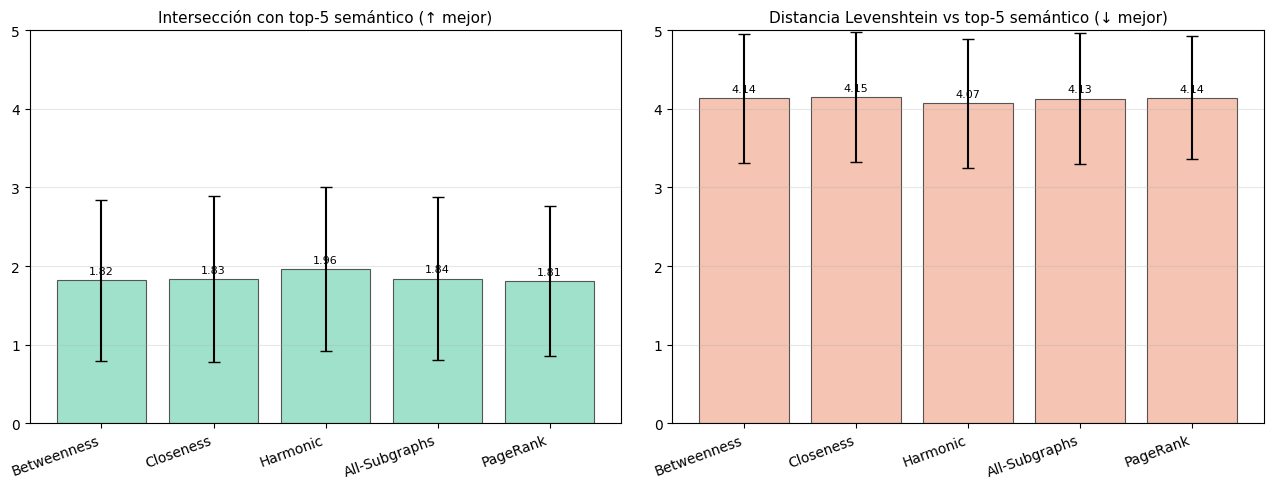

In [13]:
# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = list(range(len(METODOS)))

for ax, clave, titulo, color in [
    (axes[0], "Intersección", "Intersección con top-5 semántico (↑ mejor)", "#9FE1CB"),
    (axes[1], "Levenshtein", "Distancia Levenshtein vs top-5 semántico (↓ mejor)", "#F5C4B3"),
]:
    medias = [r[f"{clave} media"] for r in resumen]
    stds = [r[f"{clave} std"] for r in resumen]
    bars = ax.bar(x, medias, yerr=stds, capsize=4, color=color,
                  edgecolor="#555555", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(METODOS, rotation=20, ha="right")
    ax.set_title(titulo, fontsize=11)
    ax.set_ylim(0, 5)
    ax.grid(axis="y", alpha=0.3)
    for b, m in zip(bars, medias):
        ax.text(b.get_x() + b.get_width() / 2, m + 0.08, f"{m:.2f}",
                ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("top5_centrality_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Distribuciones (histogramas)

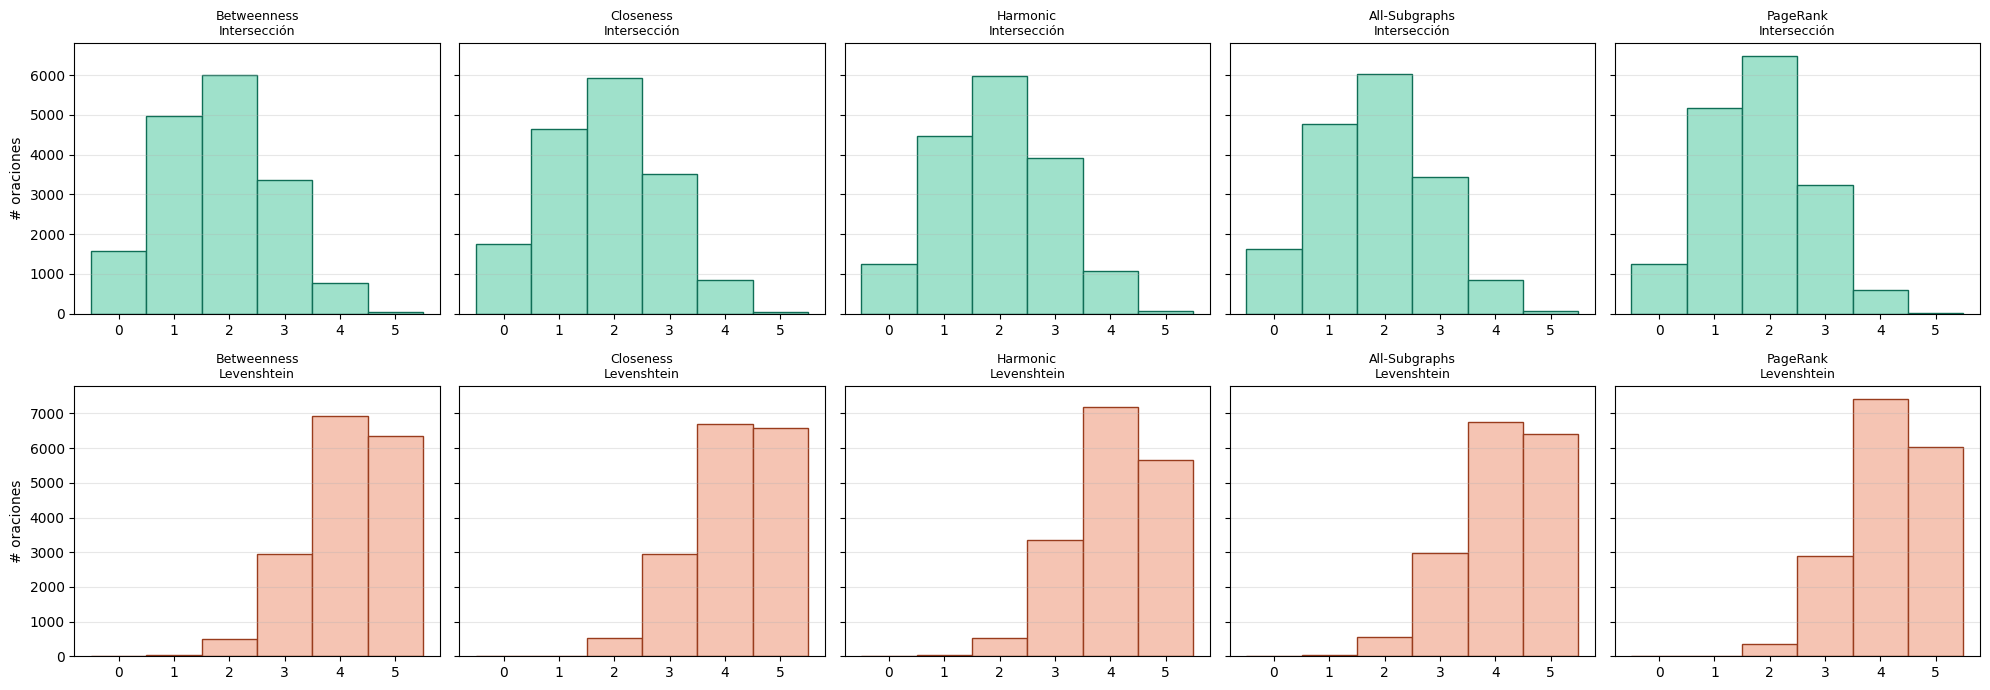

In [14]:
fig, axes = plt.subplots(2, len(METODOS), figsize=(4 * len(METODOS), 7), sharey="row")

for col, metodo in enumerate(METODOS):
    inter = [f[f"inter_{metodo}"] for f in filas]
    leven = [f[f"leven_{metodo}"] for f in filas]

    axes[0, col].hist(inter, bins=range(0, 7), color="#9FE1CB",
                       edgecolor="#0F6E56", align="left")
    axes[0, col].set_title(f"{metodo}\nIntersección", fontsize=9)
    axes[0, col].set_xticks(range(0, 6))
    axes[0, col].grid(axis="y", alpha=0.3)

    axes[1, col].hist(leven, bins=range(0, 7), color="#F5C4B3",
                       edgecolor="#993C1D", align="left")
    axes[1, col].set_title(f"{metodo}\nLevenshtein", fontsize=9)
    axes[1, col].set_xticks(range(0, 6))
    axes[1, col].grid(axis="y", alpha=0.3)

axes[0, 0].set_ylabel("# oraciones")
axes[1, 0].set_ylabel("# oraciones")
plt.tight_layout()
plt.show()